In [1]:
# 对于TensorFlow
import tensorflow as tf
tf.keras.backend.clear_session()

2025-04-14 12:39:37.985433: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Configure GPU memory growth dynamically to prevent memory allocation errors
import tensorflow as tf

# Get list of available GPUs
gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    try:
        # Enable memory growth for each GPU - allocates memory as needed
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [3]:
import tensorflow as tf

# Check if GPU is available
physical_devices = tf.config.list_physical_devices('GPU')
print("Available physical GPU devices:", physical_devices)

if len(physical_devices) > 0:
    try:
        # Configure RTX 4090 (16GB) - Set memory limit
        # Limit GPU memory to 16GB to prevent out-of-memory errors
        tf.config.set_logical_device_configuration(
            physical_devices[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=1024 * 16)]  # 16GB
        )
        print("GPU memory limit set successfully")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")

物理GPU设备: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU内存限制设置成功


In [4]:
#Importing libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn
import os
import shutil
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score


In [5]:
CONFIGURATION = {
    'MODEL_NAME': 'ViT',
    'ZOOM': 100, # 40 / 100 / 200  400  -> Number of images: 1995 + 2081 + 2013 + 1820
    'DATA_SPLIT': 'custom', # original / custom
    'N_EPOCHS': 200,
    'BATCH_SIZE': 64,
    'IMAGE_SIZE': 160,
    'PATCH_SIZE': 16,
    'LR': 1e-3,
    'WEIGHT_DECAY': 0.0001,
    'DROP_OUT': 0.7,
    'SPT': True, # Shifted Patch Tokenization 
}

In [6]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from IPython.display import display, Image

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Define data paths
BASE_PATH = '/root/autodl-tmp/BACH/ICIAR2018_BACH_Challenge/ICIAR2018_BACH_Challenge'
PHOTOS_PATH = '/root/autodl-tmp/BACH/ICIAR2018_BACH_Challenge/ICIAR2018_BACH_Challenge/Photos'
CSV_PATH = os.path.join(PHOTOS_PATH, 'microscopy_ground_truth.csv')

# Check if paths exist
print(f"CSV file exists: {os.path.exists(CSV_PATH)}")
print(f"Photos directory exists: {os.path.exists(PHOTOS_PATH)}")

# Read CSV file containing image filenames and their classes
df = pd.read_csv(CSV_PATH, header=None, names=['filename', 'class'])

# Display first 5 rows of the dataset
print("\nFirst 5 rows of dataset:")
display(df.head())

# Show class distribution
print("\nOriginal class distribution:")
print(df['class'].value_counts())


CSV文件存在: True
照片目录存在: True

数据集前5行:


,filename,class
0,n001.tif,Normal
1,n002.tif,Normal
2,n003.tif,Normal
3,n004.tif,Normal
4,n005.tif,Normal



原始类别分布:
Normal      100
Benign      100
InSitu      100
Invasive    100
Name: class, dtype: int64


In [7]:
# Modified CSV file reading approach - key modification here
if os.path.exists(CSV_PATH):
    # Read CSV file without header, manually specify column names
    df = pd.read_csv(CSV_PATH, header=None, names=['filename', 'class'])
    
    # Display first few rows of dataset
    print("\nFirst 5 rows of dataset:")
    display(df.head())
    
    # Check class distribution
    print("\nOriginal class distribution:")
    print(df['class'].value_counts())
    
    # Verify existence of image files
    image_exists_count = 0
    for filename in df['filename']:
        image_path = os.path.join(PHOTOS_PATH, filename)
        if os.path.exists(image_path):
            image_exists_count += 1
    
    print(f"\nNumber of images found: {image_exists_count}/{len(df)}")


数据集前5行:


,filename,class
0,n001.tif,Normal
1,n002.tif,Normal
2,n003.tif,Normal
3,n004.tif,Normal
4,n005.tif,Normal



原始类别分布:
Normal      100
Benign      100
InSitu      100
Invasive    100
Name: class, dtype: int64

成功找到的图像数量: 0/400


In [8]:
# Fix image file locations
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from IPython.display import display

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Base paths
BASE_PATH = '/root/autodl-tmp/BACH/ICIAR2018_BACH_Challenge/ICIAR2018_BACH_Challenge'
PHOTOS_PATH = os.path.join(BASE_PATH, 'Photos')
CSV_PATH = os.path.join(PHOTOS_PATH, 'microscopy_ground_truth.csv')

# Class subdirectories
CLASS_PATHS = {
    'Normal': os.path.join(PHOTOS_PATH, 'Normal'),
    'Benign': os.path.join(PHOTOS_PATH, 'Benign'), 
    'InSitu': os.path.join(PHOTOS_PATH, 'InSitu'),
    'Invasive': os.path.join(PHOTOS_PATH, 'Invasive')
}

# Check if paths exist
print(f"CSV file exists: {os.path.exists(CSV_PATH)}")
print(f"Photos directory exists: {os.path.exists(PHOTOS_PATH)}")

# Check class directories
for cls, path in CLASS_PATHS.items():
    print(f"{cls} directory exists: {os.path.exists(path)}")

# Read CSV file if exists
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH, header=None, names=['filename', 'class'])
    
    # Display first rows
    print("\nFirst 5 rows of dataset:")
    display(df.head())
    
    # Show class distribution
    print("\nOriginal class distribution:")
    print(df['class'].value_counts())
else:
    # Create dataset from directory structure if CSV not found
    print("\nCSV not found, creating dataset from directories...")
    
    data = []
    for cls, path in CLASS_PATHS.items():
        if os.path.exists(path):
            files = [f for f in os.listdir(path) if f.endswith('.tif')]
            for file in files:
                data.append({'filename': file, 'class': cls})
    
    df = pd.DataFrame(data)
    print("\nDataset created from directories:")
    display(df.head())
    print("\nClass distribution:")
    print(df['class'].value_counts())

# Check if image files exist (considering class directories)
image_exists_count = 0
for idx, row in df.iterrows():
    filename = row['filename']
    cls = row['class']
    # Build image path including class directory
    image_path = os.path.join(CLASS_PATHS.get(cls, ''), filename)
    
    if os.path.exists(image_path):
        image_exists_count += 1
    
    # Print first few paths for debugging
    if idx < 5:
        print(f"Class: {cls}, Filename: {filename}")
        print(f"Attempted path: {image_path}")
        print(f"Path exists: {os.path.exists(image_path)}\n")

print(f"\nImages found: {image_exists_count}/{len(df)}")

# Try alternative methods if no images found
if image_exists_count == 0:
    print("\nTrying to locate image files in subdirectories...")
    
    # Check files in each class directory
    for cls, path in CLASS_PATHS.items():
        if os.path.exists(path):
            files = [f for f in os.listdir(path) if f.endswith('.tif')]
            print(f"Number of .tif files in {cls} directory: {len(files)}")
            if files:
                print(f"First 5 files: {files[:5]}")
                
                # Check if CSV filenames need adjustment
                if df[df['class'] == cls].shape[0] > 0:
                    csv_filenames = df[df['class'] == cls]['filename'].tolist()
                    common_files = set(csv_filenames).intersection(set(files))
                    print(f"Files common to CSV and directory: {len(common_files)}")
                    
                    # Print examples if no common files found
                    if len(common_files) == 0 and len(files) > 0 and len(csv_filenames) > 0:
                        print(f"CSV filename examples: {csv_filenames[:3]}")
                        print(f"Directory filename examples: {files[:3]}")
    
    # Check if CSV filenames need adjustment
    print("\nChecking if CSV filenames need adjustment...")
    
    # Parse filename prefixes and count occurrences
    prefix_counts = {}
    for idx, row in df.iterrows():
        filename = row['filename']
        prefix = ''.join([c for c in filename if not c.isdigit() and c != '.'])
        prefix_counts[prefix] = prefix_counts.get(prefix, 0) + 1
    
    print("Filename prefix counts:")
    for prefix, count in prefix_counts.items():
        print(f"{prefix}: {count} files")

CSV文件存在: True
照片主目录存在: True
Normal目录存在: True
Benign目录存在: True
InSitu目录存在: True
Invasive目录存在: True

数据集前5行:


,filename,class
0,n001.tif,Normal
1,n002.tif,Normal
2,n003.tif,Normal
3,n004.tif,Normal
4,n005.tif,Normal



原始类别分布:
Normal      100
Benign      100
InSitu      100
Invasive    100
Name: class, dtype: int64
类别: Normal, 文件名: n001.tif
尝试路径: /root/autodl-tmp/BACH/ICIAR2018_BACH_Challenge/ICIAR2018_BACH_Challenge/Photos/Normal/n001.tif
路径存在: True

类别: Normal, 文件名: n002.tif
尝试路径: /root/autodl-tmp/BACH/ICIAR2018_BACH_Challenge/ICIAR2018_BACH_Challenge/Photos/Normal/n002.tif
路径存在: True

类别: Normal, 文件名: n003.tif
尝试路径: /root/autodl-tmp/BACH/ICIAR2018_BACH_Challenge/ICIAR2018_BACH_Challenge/Photos/Normal/n003.tif
路径存在: True

类别: Normal, 文件名: n004.tif
尝试路径: /root/autodl-tmp/BACH/ICIAR2018_BACH_Challenge/ICIAR2018_BACH_Challenge/Photos/Normal/n004.tif
路径存在: True

类别: Normal, 文件名: n005.tif
尝试路径: /root/autodl-tmp/BACH/ICIAR2018_BACH_Challenge/ICIAR2018_BACH_Challenge/Photos/Normal/n005.tif
路径存在: True


成功找到的图像数量: 400/400


In [9]:
# Dataset split and preprocessing
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Base paths and class subdirectories
BASE_PATH = '/root/autodl-tmp/BACH/ICIAR2018_BACH_Challenge/ICIAR2018_BACH_Challenge'
PHOTOS_PATH = os.path.join(BASE_PATH, 'Photos')
# Dictionary mapping class names to their respective paths
CLASS_PATHS = {
    'Normal': os.path.join(PHOTOS_PATH, 'Normal'),
    'Benign': os.path.join(PHOTOS_PATH, 'Benign'), 
    'InSitu': os.path.join(PHOTOS_PATH, 'InSitu'),
    'Invasive': os.path.join(PHOTOS_PATH, 'Invasive')
}

# Filter out Normal class, keep Benign, InSitu and Invasive
filtered_df = df[df['class'] != 'Normal'].copy()

# Create binary labels: Benign(0) and Malignant(1) 
filtered_df['binary_class'] = filtered_df['class'].apply(lambda x: 0 if x == 'Benign' else 1)

# Display class distribution after binary classification
print("Class distribution after binary classification:")
print(filtered_df['binary_class'].value_counts())
print("\nBinary class distribution by original classes:")
print(filtered_df.groupby('binary_class')['class'].value_counts())

二分类后的类别分布:
1    200
0    100
Name: binary_class, dtype: int64

按原始类别分组的二分类分布:
binary_class  class   
0             Benign      100
1             InSitu      100
              Invasive    100
Name: class, dtype: int64


In [10]:

# Split dataset into training and test sets while maintaining class balance
X_train, X_test, y_train, y_test = train_test_split(
    filtered_df['filename'], 
    filtered_df['binary_class'],
    test_size=0.2,  # 80% train, 20% test
    random_state=SEED,
    stratify=filtered_df['binary_class']  # Ensure balanced class distribution
)

# Create DataFrames for train and test sets
train_df = pd.DataFrame({
    'filename': X_train,
    'binary_class': y_train
}).reset_index(drop=True)

test_df = pd.DataFrame({
    'filename': X_test,
    'binary_class': y_test
}).reset_index(drop=True)

# Add original class labels back to DataFrames
train_df = train_df.merge(filtered_df[['filename', 'class']], on='filename', how='left')
test_df = test_df.merge(filtered_df[['filename', 'class']], on='filename', how='left')

# Print split results
print("Training set size:", len(train_df))
print("Test set size:", len(test_df))
print("\nTraining set class distribution:")
print(train_df['binary_class'].value_counts())
print("\nTraining set original class distribution:")
print(train_df['class'].value_counts())

训练集大小: 240
测试集大小: 60

训练集类别分布:
1    160
0     80
Name: binary_class, dtype: int64

训练集原始类别分布:
Invasive    80
InSitu      80
Benign      80
Name: class, dtype: int64


In [11]:
# Balance the training set samples using random oversampling
# Use RandomOverSampler to oversample minority class
from imblearn.over_sampling import RandomOverSampler

# Get filenames and labels from training set
# Reshape to 2D array for RandomOverSampler
X_train_files = train_df['filename'].values.reshape(-1, 1)  
y_train_labels = train_df['binary_class'].values

# Apply random oversampling
oversampler = RandomOverSampler(random_state=SEED)
X_resampled, y_resampled = oversampler.fit_resample(X_train_files, y_train_labels)

# Create balanced training DataFrame
balanced_train_df = pd.DataFrame({
    'filename': X_resampled.flatten(),  # Convert back to 1D
    'binary_class': y_resampled
})

# Add original class labels
balanced_train_df = balanced_train_df.merge(filtered_df[['filename', 'class']], on='filename', how='left')

# Print distribution after balancing
print("\nBalanced training set size:", len(balanced_train_df))
print("Class distribution after balancing:")
print(balanced_train_df['binary_class'].value_counts())
print("\nOriginal class distribution after balancing:")
print(balanced_train_df['class'].value_counts())


均衡后的训练集大小: 320
均衡后的训练集类别分布:
1    160
0    160
Name: binary_class, dtype: int64

均衡后的训练集原始类别分布:
Benign      160
Invasive     80
InSitu       80
Name: class, dtype: int64


In [12]:
# Image preprocessing: resize, standardize color channels and normalize
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Function to preprocess images by resizing, converting to RGB and normalizing pixel values
def preprocess_image(image_path, target_size=(160, 160)):
    """
    Preprocess a single image by:
    1. Loading the image
    2. Converting BGR to RGB
    3. Resizing to target dimensions
    4. Normalizing pixel values to [0,1]
    """
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Failed to read image: {image_path}")
        return None
    
    # Convert BGR to RGB color space
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Resize image to target dimensions
    image = cv2.resize(image, target_size)
    
    # Normalize pixel values to [0,1] range
    image = image.astype(np.float32) / 255.0
    
    return image

In [13]:
# Create image data and label arrays
def create_dataset(dataframe, target_size=(160, 160)):

    # Initialize lists to store processed images and their labels
    images = []
    labels = []
    failed_count = 0
    
    for idx, row in dataframe.iterrows():
        filename = row['filename']
        cls = row['class']  # Original class label
        binary_class = row['binary_class']  # Binary class label (0/1)
        
        # Build image path based on class directory structure
        image_path = os.path.join(CLASS_PATHS[cls], filename)
        
        # Preprocess image (resize, convert color, normalize)
        image = preprocess_image(image_path, target_size)
        
        if image is not None:
            images.append(image)
            labels.append(binary_class)
        else:
            failed_count += 1
    
    if failed_count > 0:
        print(f"Warning: Failed to process {failed_count} images")
    
    return np.array(images), np.array(labels)

In [14]:
# Process training images
print("Processing training images...")
training_images, training_labels = create_dataset(balanced_train_df)

# Process test images 
print("Processing test images...")
test_images, test_labels = create_dataset(test_df)

# Print dataset shapes and statistics
print(f"\nTraining set shape: {training_images.shape}")  # (num_samples, height, width, channels)
print(f"Training labels shape: {training_labels.shape}") # (num_samples,)
print(f"Test set shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

# Check pixel value ranges to verify normalization
print(f"\nTraining set pixel range: [{training_images.min()}, {training_images.max()}]")
print(f"Test set pixel range: [{test_images.min()}, {test_images.max()}]")

正在处理训练集图像...
正在处理测试集图像...

训练集形状: (320, 160, 160, 3)
训练集标签形状: (320,)
测试集形状: (60, 160, 160, 3)
测试集标签形状: (60,)

训练集像素值范围: [0.0, 1.0]
测试集像素值范围: [0.0, 1.0]



Training set preview:


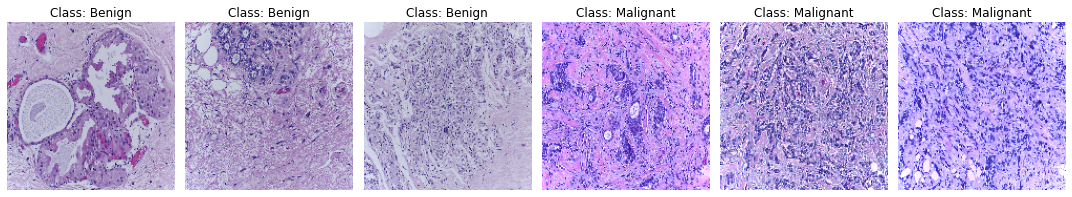

In [15]:
# Display both benign and malignant sample images
def show_samples(images, labels, n_per_class=3):
    """Display n_per_class sample images for each class"""
    classes = ["Benign", "Malignant"]
    n_total = n_per_class * 2
    
    # Create subplots
    fig, axs = plt.subplots(1, n_total, figsize=(15, 3))
    
    # Find indices for each class
    for class_idx in range(2):
        class_indices = np.where(labels == class_idx)[0][:n_per_class]
        
        # Display images for each class
        for i, idx in enumerate(class_indices):
            plot_idx = class_idx * n_per_class + i
            axs[plot_idx].imshow(images[idx])
            axs[plot_idx].set_title(f"Class: {classes[class_idx]}")
            axs[plot_idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Show training set samples
print("\nTraining set preview:")
show_samples(training_images, training_labels)

Setting up data augmentation for training set...

Data Augmentation Preview:


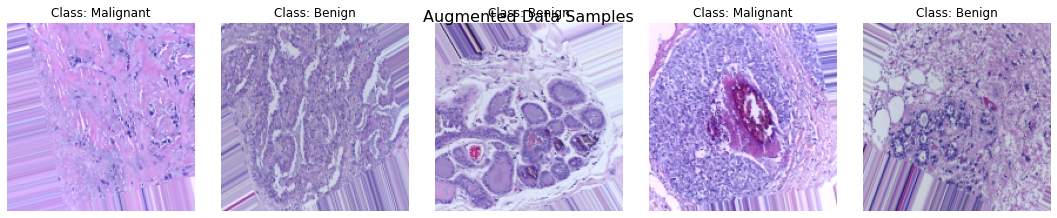


Data Augmentation Configuration:
- Rotation range: ±90 degrees
- Zoom range: ±20%
- Width shift: ±20% of width
- Height shift: ±20% of height
- Horizontal flip: enabled
- Vertical flip: enabled
- Fill mode: nearest

Data Generator Information:
- Batch size: 32
- Steps per epoch: 10
- Total training samples: 240


In [16]:
# Import required libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Apply data augmentation to training set
print("Setting up data augmentation for training set...")
data_gen = ImageDataGenerator(
    rotation_range=90,        # Random rotation up to 90 degrees
    zoom_range=0.2,           # Random zoom of ±20% of original size
    width_shift_range=0.2,    # Horizontal shift up to ±20% of width
    height_shift_range=0.2,   # Vertical shift up to ±20% of height
    horizontal_flip=True,     # Random horizontal flips
    vertical_flip=True,       # Random vertical flips
    fill_mode='nearest'       # Fill mode: use nearest pixel value
)

# Configure data generator
batch_size = 32
train_generator = data_gen.flow(
    training_images, 
    training_labels,
    batch_size=batch_size,
    shuffle=True
)

# Validate data augmentation - show some augmented samples
def show_augmented_samples(generator, n_samples=5):
    """Display samples after data augmentation"""
    # Get a batch of data
    images, labels = next(generator)
    
    # Display augmented images
    fig, axes = plt.subplots(1, n_samples, figsize=(15, 3))
    classes = ["Benign", "Malignant"]
    
    for i in range(n_samples):
        axes[i].imshow(images[i])
        axes[i].set_title(f"Class: {classes[int(labels[i])]}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Augmented Data Samples', fontsize=16)
    plt.show()

# Show augmented samples
print("\nData Augmentation Preview:")
show_augmented_samples(train_generator)

# Print data augmentation config and generator info
print("\nData Augmentation Configuration:")
print(f"- Rotation range: ±90 degrees")
print(f"- Zoom range: ±20%")
print(f"- Width shift: ±20% of width")
print(f"- Height shift: ±20% of height")
print(f"- Horizontal flip: enabled")
print(f"- Vertical flip: enabled")
print(f"- Fill mode: nearest")

print("\nData Generator Information:")
print(f"- Batch size: {batch_size}")
print(f"- Steps per epoch: {len(train_generator)}")
print(f"- Total training samples: {len(X_train)}")


In [17]:
import math
import numpy as np
import tensorflow as tf
from tensorflow import keras
# import tensorflow_addons as tfa
import matplotlib.pyplot as plt
from tensorflow.keras import layers


# Setting seed for reproducibiltiy
SEED = 42
keras.utils.set_random_seed(SEED)

NUM_CLASSES = 2
INPUT_SHAPE = (CONFIGURATION['IMAGE_SIZE'], CONFIGURATION['IMAGE_SIZE'], 3)

# DATA
BATCH_SIZE = CONFIGURATION['BATCH_SIZE']

# AUGMENTATION
IMAGE_SIZE = CONFIGURATION['IMAGE_SIZE']
PATCH_SIZE = CONFIGURATION['PATCH_SIZE']
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

# OPTIMIZER
LEARNING_RATE = CONFIGURATION['LR']
WEIGHT_DECAY = CONFIGURATION['WEIGHT_DECAY']

# TRAINING
EPOCHS = CONFIGURATION['N_EPOCHS']

# ARCHITECTURE  
LAYER_NORM_EPS = 1e-6
TRANSFORMER_LAYERS = 6
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_UNITS = [
    PROJECTION_DIM * 2,
    PROJECTION_DIM,
]
MLP_HEAD_UNITS = [512, 128]





In [18]:
class ShiftedPatchTokenization(layers.Layer):
    def __init__(
        self,
        image_size,
        patch_size,
        num_patches,
        projection_dim,
        vanilla=False,
        name=None,  
        **kwargs,
    ):
        super().__init__(name=name, **kwargs)
        self.image_size = image_size
        self.patch_size = patch_size
        self.half_patch = patch_size // 2
        self.projection_dim = projection_dim
        self.num_patches = num_patches
        self.vanilla = vanilla
        
       
        self.patch_norm = layers.BatchNormalization(
            name=f"{name}_patch_norm" if name else "patch_norm"
        )
        
        self.patch_proj_1 = layers.Dense(
            projection_dim, 
            activation='gelu',
            kernel_regularizer=regularizers.l2(1e-4),
            name=f"{name}_patch_proj_1" if name else "patch_proj_1"
        )
        
        self.patch_proj_2 = layers.Dense(
            projection_dim,
            kernel_regularizer=regularizers.l2(1e-4),
            name=f"{name}_patch_proj_2" if name else "patch_proj_2"
        )
        
        self.patch_dropout = layers.Dropout(
            0.1,
            name=f"{name}_patch_dropout" if name else "patch_dropout"
        )
        
        self.patch_layer_norm = layers.LayerNormalization(
            epsilon=LAYER_NORM_EPS,
            name=f"{name}_patch_layer_norm" if name else "patch_layer_norm"
        )

    def extract_patches(self, images):
        # Add noise to input images for regularization
        noise = tf.random.normal(
            shape=tf.shape(images), 
            mean=0.0, 
            stddev=0.01,
            name="patch_noise"
        )
        images = images + noise
        
        # Extract patches from images using sliding window
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patches = tf.reshape(patches, [tf.shape(images)[0], -1, self.patch_size * self.patch_size * 3])
        return patches

    def call(self, images, training=None):
        if self.vanilla:
            # Simple patch processing without shifting
            patches = self.extract_patches(images)
            patches = self.patch_norm(patches, training=training)
            patches = self.patch_proj_1(patches)
            patches = self.patch_dropout(patches, training=training)
            patches = self.patch_layer_norm(patches)
        else:
            # Process original patches
            patches = self.extract_patches(images)
            patches = self.patch_norm(patches, training=training)
            patches = self.patch_proj_1(patches)
            
            # Process shifted patches
            shifted_images = tf.roll(
                images, 
                shift=[self.half_patch, self.half_patch], 
                axis=[1, 2],
                name="shifted_images"
            )
            shifted_patches = self.extract_patches(shifted_images)
            shifted_patches = self.patch_norm(shifted_patches, training=training)
            shifted_patches = self.patch_proj_1(shifted_patches)
            
            # Attention fusion between original and shifted patches
            attention_weights = tf.nn.softmax(
                tf.matmul(patches, shifted_patches, transpose_b=True),
                name="attention_weights"
            )
            attention_output = tf.matmul(attention_weights, shifted_patches)
            
            # Concatenate original and attention-weighted patches
            patches = tf.concat(
                [patches, attention_output], 
                axis=1,
                name="concat_patches"
            )
            
            # Trim patches to match expected number
            patches = tf.cond(
                tf.greater(tf.shape(patches)[1], self.num_patches),
                lambda: patches[:, :self.num_patches, :],
                lambda: patches
            )
            
            patches = self.patch_dropout(patches, training=training)
            patches = self.patch_proj_2(patches)
            patches = self.patch_layer_norm(patches)
        
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({
            "image_size": self.image_size,
            "patch_size": self.patch_size,
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
            "vanilla": self.vanilla,
        })
        return config

In [19]:
# 1. EfficientNetV2 Bottleneck
def bottleneck0(inputs):
    # Initialize EfficientNetV2 backbone network
    backbone = tf.keras.applications.EfficientNetV2B0(
        weights='imagenet', 
        include_top=False,
        input_tensor=inputs  # Directly specify input tensor
    )
    
    # Feature extraction and processing
    x = backbone.output  # Get backbone network output
    x = layers.GlobalAveragePooling2D(
        name='efficient_gap'
    )(x)
    x = layers.BatchNormalization(
        name='efficient_bn'
    )(x)
    x = layers.Dense(
        256, 
        activation='relu',
        name='efficient_dense'
    )(x)
    x = layers.Flatten(
        name='efficient_flatten'
    )(x)
    
    return x

In [20]:
class PatchEncoder(layers.Layer):
    def __init__(
        self,
        num_patches,
        projection_dim,
        name=None,
        **kwargs
    ):
        super().__init__(name=name, **kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        
        # Create embedding layer for positional encoding
        self.pos_embedding = layers.Embedding(
            input_dim=num_patches, 
            output_dim=projection_dim,
            name=f"{name}_pos_embedding" if name else "pos_embedding"
        )

    def call(self, patch_input):  # patch_input: tensor of patch features
        # Generate sequential position indices (0 to num_patches-1)
        position_indices = tf.range(
            start=0, 
            limit=self.num_patches, 
            delta=1,
            name="position_indices"
        )
        
        # Convert indices to positional embeddings
        position_encodings = self.pos_embedding(position_indices)
        
        # Add positional information to patch features
        encoded_patches = patch_input + position_encodings
        
        return encoded_patches

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim
        })
        return config

In [21]:
class MultiHeadAttentionLSA(tf.keras.layers.MultiHeadAttention):
    def __init__(self, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        # Initialize learnable temperature parameter for LSA
        self.lsa_temperature = tf.Variable(
            math.sqrt(float(self._key_dim)), 
            trainable=True,
            name=f"{name}_lsa_temperature" if name else "lsa_temperature"
        )

    def _compute_attention(
        self, 
        query_tensor, 
        key_tensor, 
        value_tensor, 
        attention_mask=None, 
        training=None
    ):
        # Scale query by learnable temperature
        lsa_scaled_query = tf.multiply(
            query_tensor, 
            1.0 / self.lsa_temperature,
            name="lsa_scaled_query"
        )
        
        # Compute attention scores using dot product
        lsa_raw_attention_scores = tf.einsum(
            self._dot_product_equation, 
            key_tensor, 
            lsa_scaled_query,
            name="lsa_raw_attention_scores"
        )
        
        # Apply mask and softmax activation
        lsa_masked_scores = self._masked_softmax(
            lsa_raw_attention_scores, 
            attention_mask
        )
        
        # Apply dropout for regularization
        lsa_score_dropout = self._dropout_layer(
            lsa_masked_scores, 
            training=training
        )
        
        # Compute final attention output
        lsa_attention_result = tf.einsum(
            self._combine_equation, 
            lsa_score_dropout, 
            value_tensor,
            name="lsa_attention_result"
        )
        
        return lsa_attention_result, lsa_masked_scores

    def get_config(self):
        base_config = super().get_config()
        # Add LSA-specific config
        base_config.update({
            "lsa_temperature": self.lsa_temperature.numpy()
        })
        return base_config

In [22]:
# Multi-layer perceptron with dropout for transformer architecture
def mlp(x, hidden_units, dropout_rate=0.1, name_prefix="mlp"):

    for i, units in enumerate(hidden_units):
        x = layers.Dense(
            units, 
            activation=tf.nn.gelu,
            name=f'{name_prefix}_dense_{i}'
        )(x)
        x = layers.Dropout(
            dropout_rate,
            name=f'{name_prefix}_dropout_{i}'
        )(x)
    return x

# Create mask matrix where diagonal elements are 0 and others are 1
# Used to prevent self-attention in transformer
diag_attn_mask = 1 - tf.eye(NUM_PATCHES)
diag_attn_mask = tf.cast([diag_attn_mask], dtype=tf.int8)

# Configuration method for serialization
def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return config    

2025-04-14 12:39:49.258130: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-14 12:39:49.843600: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090 D, pci bus id: 0000:39:00.0, compute capability: 8.9


In [23]:
def create_cnn_classifier():
    """Creates a CNN classifier model with EfficientNetV2 backbone"""
    inputs = layers.Input(shape=INPUT_SHAPE)
    
    # Use EfficientNetV2 as CNN backbone network
    x = bottleneck0(inputs)
    
    # Add classification head with regularization and dropout
    # First dense layer with 512 units
    x = layers.Dense(512, activation='relu', 
                    kernel_regularizer=regularizers.l2(CONFIGURATION['WEIGHT_DECAY']))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CONFIGURATION['DROP_OUT'])(x)
    
    # Second dense layer with 256 units
    x = layers.Dense(256, activation='relu', 
                    kernel_regularizer=regularizers.l2(CONFIGURATION['WEIGHT_DECAY']))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CONFIGURATION['DROP_OUT'])(x)
    
    # Output layer with softmax activation
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    # Create and return model
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


In [24]:
def create_vit_classifier(vanilla=True):
    """Creates a Vision Transformer (ViT) classifier model
    Args:
        vanilla: If True, uses standard ViT. If False, uses Shifted Patch Tokenization
    """
    inputs = layers.Input(shape=INPUT_SHAPE, name='input_layer')
    
    # Extract and encode image patches
    patches = ShiftedPatchTokenization(
        image_size=IMAGE_SIZE,
        patch_size=PATCH_SIZE,
        num_patches=NUM_PATCHES * (2 if not vanilla else 1),
        projection_dim=PROJECTION_DIM,
        vanilla=vanilla,
        name='patch_extraction'
    )(inputs)
    
    encoded_patches = PatchEncoder(
        num_patches=NUM_PATCHES * (2 if not vanilla else 1),
        projection_dim=PROJECTION_DIM,
        name='patch_encoding'
    )(patches)
    
    # Process patches through transformer blocks
    for i in range(TRANSFORMER_LAYERS):
        # First LayerNorm
        x1 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f'transformer_{i}_norm1'
        )(encoded_patches)
        
        # Multi-head attention layer
        attention_output = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=PROJECTION_DIM,
            dropout=0.1,
            name=f'transformer_{i}_mha'
        )(x1, x1)
        
        # First residual connection
        x2 = layers.Add(name=f'transformer_{i}_add1')([attention_output, encoded_patches])
        
        # Second LayerNorm
        x3 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f'transformer_{i}_norm2'
        )(x2)
        
        # MLP block with unique name prefix
        x3 = mlp(
            x3,
            hidden_units=TRANSFORMER_UNITS,
            dropout_rate=0.1,
            name_prefix=f'transformer_{i}_mlp'
        )
        
        # Second residual connection
        encoded_patches = layers.Add(name=f'transformer_{i}_add2')([x3, x2])
    
    # Final processing
    representation = layers.LayerNormalization(
        epsilon=1e-6,
        name='final_norm'
    )(encoded_patches)
    representation = layers.GlobalAveragePooling1D(name='gap')(representation)
    
    # Classification head
    features = layers.Dense(
        PROJECTION_DIM, 
        activation='relu',
        name='pre_classifier'
    )(representation)
    features = layers.Dropout(0.1, name='final_dropout')(features)
    outputs = layers.Dense(
        NUM_CLASSES, 
        activation='softmax',
        name='classifier'
    )(features)
    
    return keras.Model(inputs=inputs, outputs=outputs)

In [25]:
def create_hybrid_classifier(use_spt=False):
    # L2 regularization for weights
    kernel_regularizer = regularizers.l2(CONFIGURATION['WEIGHT_DECAY'] * 0.5)
    
    inputs = layers.Input(shape=INPUT_SHAPE, name='input_layer')
    
    # EfficientNetV2 branch
    efficient_branch = bottleneck0(inputs)
    
    # Vision Transformer (ViT) branch
    tokens = ShiftedPatchTokenization(
        image_size=IMAGE_SIZE,
        patch_size=PATCH_SIZE,
        num_patches=NUM_PATCHES * (2 if use_spt else 1),
        projection_dim=PROJECTION_DIM,
        vanilla=not use_spt,
        name='spt_layer'
    )(inputs)
    
    # Add positional encoding
    encoded_patches = PatchEncoder(
        num_patches=NUM_PATCHES * (2 if use_spt else 1),
        projection_dim=PROJECTION_DIM,
        name='patch_encoder'
    )(tokens)

    # Transformer encoder blocks
    for i in range(TRANSFORMER_LAYERS):
        x1 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f'transformer_norm1_{i}'
        )(encoded_patches)
        
        # Choose between LSA and regular attention
        if use_spt:
            attention_output = MultiHeadAttentionLSA(
                num_heads=NUM_HEADS, 
                key_dim=PROJECTION_DIM, 
                dropout=0.1,
                name=f'mha_lsa_{i}'
            )(x1, x1)
        else:
            attention_output = layers.MultiHeadAttention(
                num_heads=NUM_HEADS, 
                key_dim=PROJECTION_DIM, 
                dropout=0.1,
                name=f'mha_{i}'
            )(x1, x1)
            
        x2 = layers.Add(name=f'skip_connection1_{i}')([attention_output, encoded_patches])
        x3 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f'transformer_norm2_{i}'
        )(x2)
        
        x3 = mlp(
            x3, 
            hidden_units=TRANSFORMER_UNITS, 
            dropout_rate=0.1,
            name_prefix=f'mlp_{i}'
        )
        
        encoded_patches = layers.Add(name=f'skip_connection2_{i}')([x3, x2])

    # Process ViT output
    vit_features = layers.LayerNormalization(
        epsilon=1e-6,
        name='final_layer_norm'
    )(encoded_patches)
    vit_features = layers.Flatten(name='flatten')(vit_features)
    vit_features = layers.Dropout(0.2, name='vit_dropout')(vit_features)
    
    # Merge features from both branches
    combined_features = layers.Concatenate(name='feature_concat')([efficient_branch, vit_features])
    
    # Classification layers with regularization
    x = layers.Dense(
        512, 
        activation='relu',
        kernel_regularizer=kernel_regularizer,
        activity_regularizer=regularizers.l1(1e-6),
        name='dense_1'
    )(combined_features)
    x = layers.BatchNormalization(momentum=0.9, name='bn_1')(x)
    x = layers.Dropout(0.2, name='dropout_1')(x)
    
    x = layers.Dense(
        256, 
        activation='relu',
        kernel_regularizer=kernel_regularizer,
        activity_regularizer=regularizers.l1(1e-6),
        name='dense_2'
    )(x)
    x = layers.BatchNormalization(momentum=0.9, name='bn_2')(x)
    x = layers.Dropout(0.2, name='dropout_2')(x)
    
    outputs = layers.Dense(
        NUM_CLASSES, 
        activation='softmax',
        kernel_regularizer=kernel_regularizer,
        name='output'
    )(x)
    
    return keras.Model(inputs=inputs, outputs=outputs)

In [26]:

def get_metrics():
    return [keras.metrics.SparseCategoricalAccuracy(name="accuracy")]

def get_loss():
    return keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [27]:
# print data shape
print("Training images shape:", training_images.shape)
print("Training labels shape:", training_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Training images shape: (320, 160, 160, 3)
Training labels shape: (320,)
Test images shape: (60, 160, 160, 3)
Test labels shape: (60,)


In [28]:

def cosine_decay_with_warmup(epoch, total_epochs=150, warmup_epochs=5, 
                           initial_lr=1e-3, min_lr=1e-7):

    if epoch < warmup_epochs:
        return initial_lr * (epoch + 1) / warmup_epochs
    

    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    cosine_decay = 0.5 * (1 + np.cos(np.pi * progress))
    return min_lr + (initial_lr - min_lr) * cosine_decay

In [29]:
import datetime
import os
import datetime

In [30]:
def run_experiment(model, model_name='breast_cancer_model', experiment_type=''):
    """
    运行实验的函数
    Args:
        model: 要训练的模型
        model_name: 模型名称，用于保存
    """
    
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    model_save_path = os.path.join(
        '/root/autodl-tmp/BACH_data/checkpoints',
        f'{model_name}_{timestamp}'
    )
    os.makedirs(model_save_path, exist_ok=True)
    
    try:
        # create data generator
        data_gen = ImageDataGenerator(
            rotation_range=90,        # Random rotation range of 90 degrees
            zoom_range=0.2,           # Random zoom range of 20%
            width_shift_range=0.2,    # Width shift range of 20%
            height_shift_range=0.2,   # height shift range of 20%
            horizontal_flip=True,     # Random horizontal flip
            vertical_flip=True,       # Random vertical flip
            fill_mode='nearest',       # fill mode
        )
        
        # configure training data generator
        training_generator = data_gen.flow(
            training_images, 
            training_labels,
            batch_size=32,
            shuffle=True
        )

        # set callbacks
        callbacks = [
            # save best model
            tf.keras.callbacks.ModelCheckpoint(
                filepath=os.path.join(model_save_path, 'best_model.keras'),
                monitor='val_accuracy',
                save_best_only=True,
                save_format='keras',
                verbose=1,
                mode='max'
            ),
            
            tf.keras.callbacks.ModelCheckpoint(
                filepath=os.path.join(model_save_path, 'best_model.h5'),
                monitor='val_accuracy',
                save_best_only=True,
                save_format='h5',
                verbose=1,
                mode='max'
            ),
            # early stopping
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=15,
                restore_best_weights=True,
                verbose=1,
                mode='max'
            ),
            # learning rate adjustment
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_accuracy',
                factor=0.5,
                patience=3,
                mode='max',
                min_lr=1e-7,
                verbose=1,
                
            ),
            # training log
            tf.keras.callbacks.CSVLogger(
                os.path.join(model_save_path, 'training_log.csv')
            )
        ]
        
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # 0.001
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # calculate steps per epoch
        steps_per_epoch = len(training_images) // batch_size
        
        # train model
        history = model.fit(
            training_generator, 
            validation_data=(test_images, test_labels),  # test set no need to augment
            epochs=150,
            callbacks=callbacks,
            verbose=1
        )
        
        # save training history
        history_df = pd.DataFrame(history.history)
        history_df.to_csv(os.path.join(model_save_path, 'training_history.csv'))
        
        return model, history
        
    except Exception as e:
        print(f"error: {str(e)}")
        print(f"current working directory: {os.getcwd()}")
        print(f"try to save to: {model_save_path}")
        raise

In [31]:
# print configuration
print(f"Current configuration:")
print(f"SPT enabled: {CONFIGURATION['SPT']}")
print(f"Learning rate: {CONFIGURATION['LR']}")
print(f"Batch size: {CONFIGURATION['BATCH_SIZE']}")
print(f"Epochs: {CONFIGURATION['N_EPOCHS']}")


hybrid_vit_spt = create_hybrid_classifier(use_spt=CONFIGURATION['SPT'])
model_spt, history_spt = run_experiment(
    hybrid_vit_spt, 
    model_name='vit',
    experiment_type='hybrid_spt'  
)

Current configuration:
SPT enabled: True
Learning rate: 0.001
Batch size: 64
Epochs: 200
Epoch 1/150


2025-04-14 12:40:05.397433: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2025-04-14 12:40:07.327515: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-04-14 12:40:07.335644: W tensorflow/stream_executor/gpu/asm_compiler.cc:230] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 8.9
2025-04-14 12:40:07.335662: W tensorflow/stream_executor/gpu/asm_compiler.cc:233] Used ptxas at ptxas
2025-04-14 12:40:07.335749: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] UNIMPLEMENTED: ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


10/10 [==============================] - ETA: 0s - loss: 1.2751 - accuracy: 0.5750
Epoch 1: val_accuracy improved from -inf to 0.66667, saving model to /root/autodl-tmp/BACH_data/checkpoints/vit_20250414_123952/best_model.keras

Epoch 1: val_accuracy improved from -inf to 0.66667, saving model to /root/autodl-tmp/BACH_data/checkpoints/vit_20250414_123952/best_model.h5
10/10 [==============================] - 22s 712ms/step - loss: 1.2751 - accuracy: 0.5750 - val_loss: 1.5930 - val_accuracy: 0.6667 - lr: 0.0010
Epoch 2/150
10/10 [==============================] - ETA: 0s - loss: 0.8111 - accuracy: 0.6562
Epoch 2: val_accuracy did not improve from 0.66667

Epoch 2: val_accuracy did not improve from 0.66667
10/10 [==============================] - 2s 196ms/step - loss: 0.8111 - accuracy: 0.6562 - val_loss: 1.8283 - val_accuracy: 0.6667 - lr: 0.0010
Epoch 3/150
10/10 [==============================] - ETA: 0s - loss: 0.7613 - accuracy: 0.6938
Epoch 3: val_accuracy did not improve from 0.66

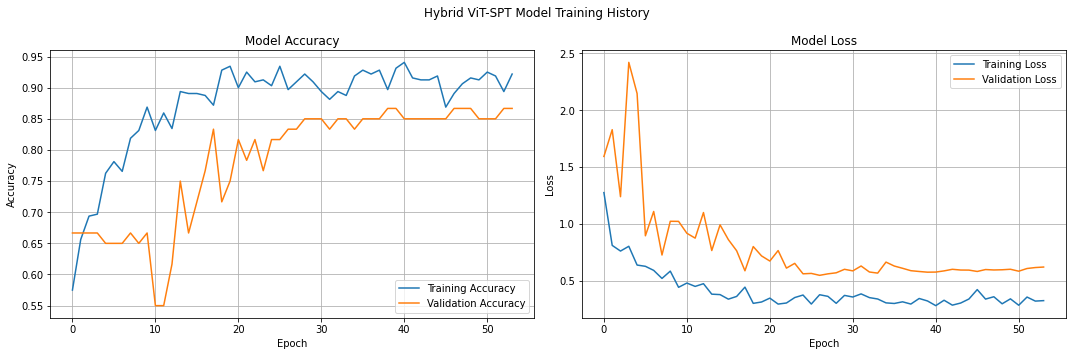


Final Training Metrics:
Training Accuracy: 0.9219
Validation Accuracy: 0.8667
Training Loss: 0.3256
Validation Loss: 0.6208


In [32]:
import matplotlib.pyplot as plt

def plot_training_history(history, title='Training History'):
    # create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='lower right')
    ax1.grid(True)
    
    # plot loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right')
    ax2.grid(True)
    
    
    plt.suptitle(title)
    plt.tight_layout()
    
    
    plt.show()
    
    # print final training metrics
    print("\nFinal Training Metrics:")
    print(f"Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")


plot_training_history(history_spt, title='Hybrid ViT-SPT Model Training History')

In [33]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import pandas as pd
from matplotlib.ticker import MaxNLocator
import matplotlib
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 12

In [34]:

import os
results_dir = '/root/autodl-tmp/results——BACH'
os.makedirs(results_dir, exist_ok=True)

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


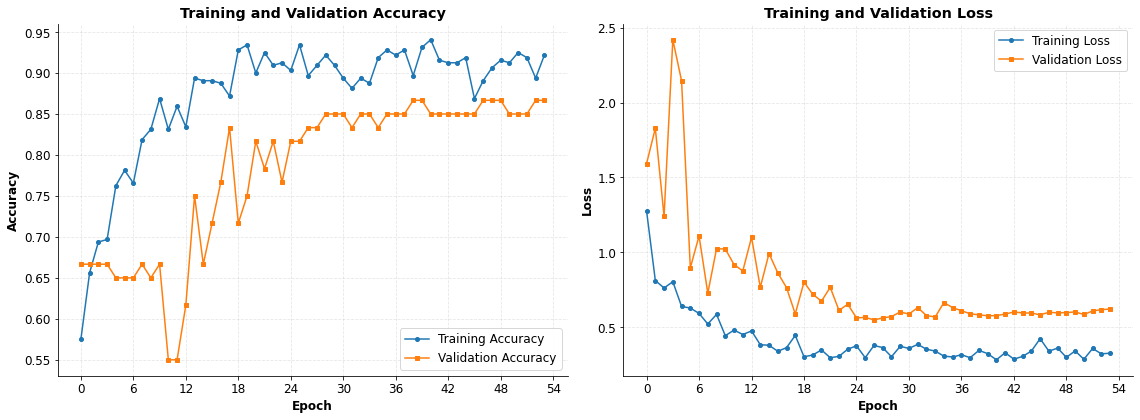

In [35]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# set common properties
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.3)
    ax.tick_params(direction='out')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# accuracy curve
ax1.plot(history_spt.history['accuracy'], marker='o', markersize=4, linestyle='-', color='#1f77b4', label='Training Accuracy')
ax1.plot(history_spt.history['val_accuracy'], marker='s', markersize=4, linestyle='-', color='#ff7f0e', label='Validation Accuracy')
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Training and Validation Accuracy', fontweight='bold')
ax1.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='lightgray')

# loss curve
ax2.plot(history_spt.history['loss'], marker='o', markersize=4, linestyle='-', color='#1f77b4', label='Training Loss')
ax2.plot(history_spt.history['val_loss'], marker='s', markersize=4, linestyle='-', color='#ff7f0e', label='Validation Loss')
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('Loss', fontweight='bold')
ax2.set_title('Training and Validation Loss', fontweight='bold')
ax2.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='lightgray')

plt.tight_layout()
plt.savefig(f"{results_dir}/accuracy_loss_curves.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_dir}/accuracy_loss_curves.pdf", bbox_inches='tight')
plt.show()


In [36]:

# evaluate test set
loss, accuracy = model_spt.evaluate(test_images, test_labels)
print(f"Test loss: {round(loss, 2)}")
print(f"Test accuracy: {round(accuracy * 100, 2)}%")

# get prediction
y_pred = model_spt.predict(test_images)

# process labels and predictions
rounded_test_labels = test_labels.flatten()
rounded_predictions = np.argmax(y_pred, axis=1)

# get positive class prediction probability (for ROC curve)
y_pred_prob = y_pred[:, 1]

# print classification report
print("\nClassification Report:")
print(classification_report(rounded_test_labels, rounded_predictions, target_names=['Benign', 'Malignant']))

2/2 [==============================] - 0s 31ms/step - loss: 0.5819 - accuracy: 0.8667
Test loss: 0.58
Test accuracy: 86.67%
2/2 [==============================] - 3s 35ms/step

Classification Report:
              precision    recall  f1-score   support

      Benign       0.83      0.75      0.79        20
   Malignant       0.88      0.93      0.90        40

    accuracy                           0.87        60
   macro avg       0.86      0.84      0.85        60
weighted avg       0.87      0.87      0.86        60



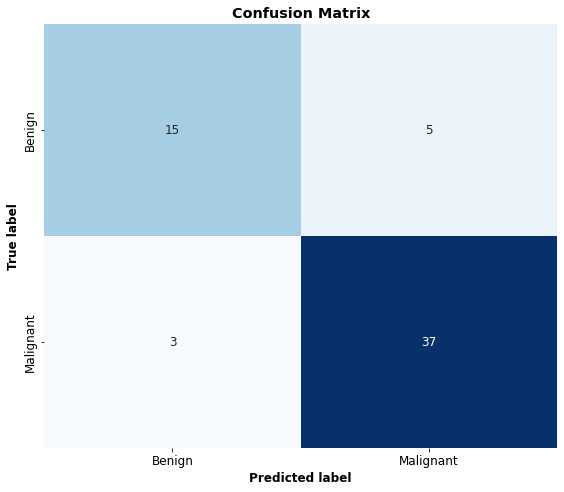

In [37]:
# get confusion matrix
cm = confusion_matrix(rounded_test_labels, rounded_predictions)
classes = ['Benign', 'Malignant']

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=classes, yticklabels=classes)
plt.ylabel('True label', fontweight='bold')
plt.xlabel('Predicted label', fontweight='bold')
plt.title('Confusion Matrix', fontweight='bold')


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{results_dir}/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_dir}/confusion_matrix.pdf", bbox_inches='tight')
plt.show()

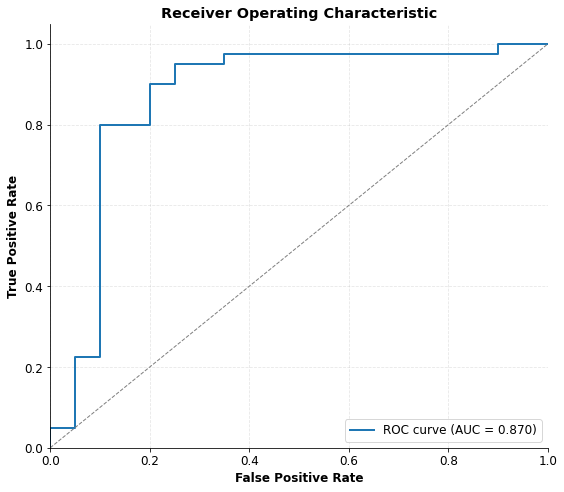

In [38]:
# get ROC curve
fpr, tpr, thresholds = roc_curve(rounded_test_labels, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='#1f77b4', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Receiver Operating Characteristic', fontweight='bold')
plt.legend(loc="lower right", frameon=True, facecolor='white', framealpha=0.9, edgecolor='lightgray')


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{results_dir}/roc_curve.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_dir}/roc_curve.pdf", bbox_inches='tight')
plt.show()

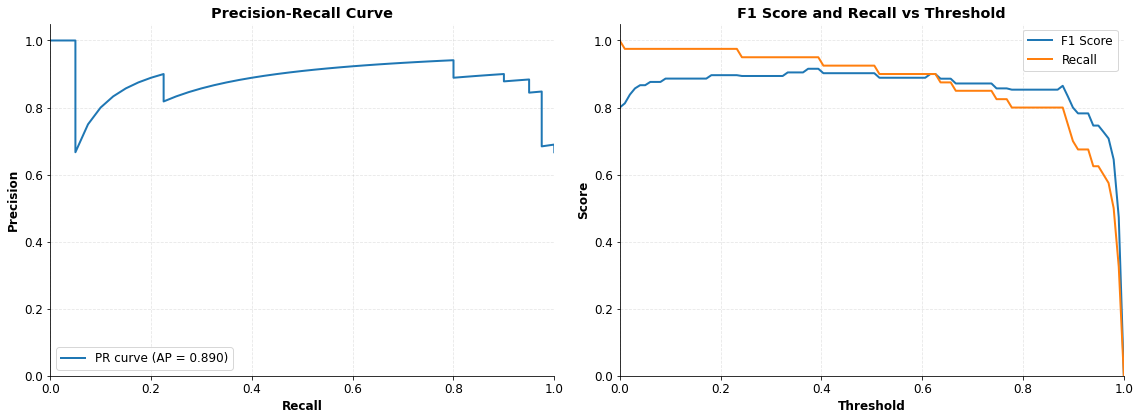

In [41]:

precision, recall, _ = precision_recall_curve(rounded_test_labels, y_pred_prob)
average_precision = average_precision_score(rounded_test_labels, y_pred_prob)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.3)
    ax.tick_params(direction='out')

# precision-recall curve
ax1.plot(recall, precision, color='#1f77b4', lw=2,
        label=f'PR curve (AP = {average_precision:.3f})')
ax1.set_xlabel('Recall', fontweight='bold')
ax1.set_ylabel('Precision', fontweight='bold')
ax1.set_title('Precision-Recall Curve', fontweight='bold')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.legend(loc="lower left", frameon=True, facecolor='white', framealpha=0.9, edgecolor='lightgray')

# F1 score and Recall vs threshold
thresholds_list = np.linspace(0, 1, 100)
f1_scores = []
recall_scores = []

for threshold in thresholds_list:
    y_pred_binary = (y_pred_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(rounded_test_labels, y_pred_binary).ravel()
    
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    f1_scores.append(f1)
    recall_scores.append(rec)

ax2.plot(thresholds_list, f1_scores, color='#1f77b4', lw=2, label='F1 Score')
ax2.plot(thresholds_list, recall_scores, color='#ff7f0e', lw=2, label='Recall')
ax2.set_xlabel('Threshold', fontweight='bold')
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('F1 Score and Recall vs Threshold', fontweight='bold')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.legend(loc="best", frameon=True, facecolor='white', framealpha=0.9, edgecolor='lightgray')

plt.tight_layout()
plt.savefig(f"{results_dir}/precision_recall_f1.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_dir}/precision_recall_f1.pdf", bbox_inches='tight')
plt.show()

In [42]:
# calculate evaluation metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall (Sensitivity)': recall,
    'F1 Score': f1,
    'Specificity': specificity,
    'AUC-ROC': roc_auc,
    'Average Precision': average_precision
}

# print evaluation metrics
print("\nEvaluation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# save evaluation metrics to csv
pd.DataFrame([metrics]).to_csv(f"{results_dir}/evaluation_metrics.csv", index=False)


Evaluation Metrics:
Accuracy: 0.8667
Precision: 0.8810
Recall (Sensitivity): 0.9250
F1 Score: 0.9024
Specificity: 0.7500
AUC-ROC: 0.8700
Average Precision: 0.8898
